<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Demography_MADDPG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Задача: в модели из произвольного количества связанных друг с другом городов построить динамически устойчивую на длительных периодах времени систему, балансирующую миграцию, обеспечивающую устойчивый экономический рост и сохранение ресурсов (их раинальное использование без исчерпания).   Начальные значения состояний задаются каждый раз случайным образом в определенных пределах (например,численность населения от 0.5 до 1.5 млн чел.) В решение задачи добавлен "шум" для создания большей вариативности и имитации случайных процессов.

In [9]:
# Задача: в моддели из произвольного количества связанных друг в другом городов построить динамически устойчивую на длительных периодах
#Многоагентное обучение с подкреплением для управления миграционной политикой
#Метод: MADDPG (Multi-Agent Deep Deterministic Policy Gradient)
#Все параметры изменяемые (стабильность сохранялась  при отклонении текущих установочных значений +/- 20%)
#Для увеличения скорости работы алгоритма с использованием нейросетей рекомендуется использовать GPU

In [10]:
import numpy as np   # Импортируем NumPy для работы с массивами и матрицей
import matplotlib.pyplot as plt   # Импортируем Matplotlib для визуализации данных
import torch   # Импортируем PyTorch для создания и обучения нейронных сетей
import torch.nn as nn   # Импортируем модуль для создания слоев нейронных сетей
import torch.optim as optim   # Импортируем модуль для оптимизации параметров модели
from collections import deque   # Импортируем Deque для хранения и управления временными рядами
import random   # Импортируем модуль для генерации случайных чисел

In [11]:
# ================== Гиперпараметры ==================
NUM_REGIONS = 7         # Общее количество регионов (агентов) в задаче - может быь установлено произвольно
EPISODES = 100          # Общее количество эпизодов для обучения
STEPS = 200             # Количество шагов в каждом эпизоде
TOTAL_STEPS = EPISODES * STEPS   # Общая длительность одного эпизода
BATCH_SIZE = 64         # Размер батча для обучения моделей
GAMMA = 0.95            # Коэффициент дисконтирования для вознаграждения
TAU = 0.01              # Параметр для мягкого обновления целевой сети
LR_ACTOR = 0.001        # Скорость обучения для сети Actor
LR_CRITIC = 0.002       # Скорость обучения для сети Critic
HIDDEN_SIZE = 64        # Размер скрытого слоя в нейронной сети

#  обеспечиваем воспроизводимость результатов
random.seed(42)         # Устанавливаем фиксированное значение seed для модуля random
# Устанавливаем фиксированное значение seed для библиотеки torch
torch.manual_seed(42)

# Если  GPU, также  seed для CUDA
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Для некоторых операций PyTorch может использовать параллельные вычисления,
# которые могут привести к разным результатам даже при одинаковом seed.
# отключим этот режим
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [12]:
# ================== Модель среды ==================
class MigrationEnvironment:
    """Симулятор миграционной системы между регионами"""  # Описание класса
    def __init__(self):  # Конструктор класса
        self.reset()      # Вызываем метод сброса для начальной инициализации

    def reset(self):
        """
        Инициализация состояния системы:
        [население, ресурсы, экономика, миграционная политика]
        """
        self.states = np.random.uniform(0.5, 1.5, (NUM_REGIONS, 4))  # Начальные значения состояний
        self.states[:,3] = 0.0  # Исходная политика нейтральная
        return self.states.copy()  # Возвращаем копию начальных состояний

    def step(self, actions):
        """
        Шаг симуляции
        Вход: действия агентов (изменения политики)
        Выход: новые состояния, награды, флаг завершения
        """
        next_states = np.zeros_like(self.states)  # Массив для новых состояний
        rewards = np.zeros(NUM_REGIONS)           # Массив для наград

        for i in range(NUM_REGIONS):  # Проходим по каждому региону
            # 1. Обновление миграционной политики
            self.states[i,3] = np.clip(self.states[i,3] + actions[i][0], -1, 1)  # Применяем изменения политики

            # 2. Расчет миграционных потоков
            migration = 0.1 * (self.states[i,3] - np.mean([self.states[j,3] for j in self.neighbors(i)]))  # Рассчитываем миграционный поток
            self.states[i,0] = np.clip(self.states[i,0] + migration, 0.1, 2.0)  # Обновляем население с учетом миграции

            # 3. Экономическая динамика
            economic_growth = 0.05 * self.states[i,0] * (1 + self.states[i,3])  # Вычисляем экономический рост
            self.states[i,2] = np.clip(self.states[i,2] + economic_growth, 0.1, 2.0)  # Обновляем экономику

            # 4. Потребление ресурсов
            resource_usage = 0.02 * self.states[i,0] * self.states[i,2]  # Рассчитываем потребление ресурсов
            self.states[i,1] = np.clip(self.states[i,1] - resource_usage, 0.1, 2.0)  # Обновляем уровень ресурсов

            # 5. Расчет наград (целевые показатели)
            rewards[i] = self._calculate_reward(i)  # Рассчитываем награду для текущего региона

        return self.states.copy(), rewards, False, {}  # Возвращаем обновленные состояния, награды и флаг завершения

    def _calculate_reward(self, region):
        """Комплексная функция вознаграждения для региона"""
        pop_balance = -abs(self.states[region,0] - 1.0)    # Баланс населения
        economy = self.states[region,2] - 1.0              # Рост экономики
        resources = -0.5*(1.0 - self.states[region,1])     # Сохранение ресурсов
        policy_align = 0.2 * np.mean([1 - abs(self.states[region,3] - self.states[j,3]) for j in self.neighbors(region)])  # Согласованность политики
        return pop_balance + economy + resources + policy_align  # Итоговая награда

    def neighbors(self, region):
        """Топология соседства регионов (кольцевая структура)"""
        return [(region-1)%NUM_REGIONS, (region+1)%NUM_REGIONS]  # Соседи по кольцу

In [13]:
# ================== Архитектура нейросетей ==================
class Actor(nn.Module):
    """Политика агента (децентрализованная)"""  # Описание класса
    def __init__(self):  # Конструктор класса
        super().__init__()  # Наследуем методы базового класса
        self.net = nn.Sequential(  # Последовательность слоев
            nn.Linear(4, HIDDEN_SIZE),  # Входной слой: 4 состояния -> HIDDEN_SIZE нейронов
            nn.ReLU(),                 # Активационная функция ReLU
            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE//2),  # Скрытый слой: HIDDEN_SIZE -> HIDDEN_SIZE/2
            nn.ReLU(),                 # Активационная функция ReLU
            nn.Linear(HIDDEN_SIZE//2, 1),  # Выходной слой: HIDDEN_SIZE/2 -> 1 выход
            nn.Tanh()                  # Функция активации Tanh для нормализации выхода в диапазон [-1, 1]
        )

    def forward(self, x):  # Метод прямого распространения
        return self.net(x)  # Пропускаем вход через сеть

class Critic(nn.Module):
    """Ценностная функция (централизованная)"""  # Описание класса
    def __init__(self):  # Конструктор класса
        super().__init__()  # Наследуем методы базового класса
        self.net = nn.Sequential(  # Последовательность слоев
            nn.Linear(4*NUM_REGIONS + NUM_REGIONS, HIDDEN_SIZE*2),  # Входной слой: 4 состояния * NUM_REGIONS + NUM_REGIONS действий -> HIDDEN_SIZE*2 нейронов
            nn.ReLU(),  # Активационная функция ReLU
            nn.Linear(HIDDEN_SIZE*2, HIDDEN_SIZE),  # Скрытый слой: HIDDEN_SIZE*2 -> HIDDEN_SIZE
            nn.ReLU(),  # Активационная функция ReLU
            nn.Linear(HIDDEN_SIZE, 1)  # Выходной слой: HIDDEN_SIZE -> 1 выход
        )

    def forward(self, states, actions):  # Метод прямого распространения
        # Конкатенация состояний и действий всех агентов
        x = torch.cat([states.flatten(1), actions.flatten(1)], dim=1)  # Объединяем состояния и действия в один вектор
        return self.net(x)  # Пропускаем объединенный вектор через сеть

In [14]:
# ================== Реализация MADDPG ==================
class MADDPG:
    """Исправленный координатор обучения"""  # Описание класса
    def _get_actions(self, states):  # Метод получения действий
        """Генерация действий с адаптивным шумом"""  # Описание метода
        actions = []  # Список для хранения действий
        for i, agent in enumerate(self.agents):  # Перебираем агентов
            state = torch.FloatTensor(states[i])  # Преобразуем состояние в тензор
            action = agent.actor(state).detach().numpy()  # Получаем действие от актора

            # Адаптивный шум с защитой от отрицательных значений
            noise_scale = 0.1 * max(0, 1 - agent.steps_done/TOTAL_STEPS)  # Масштаб шума уменьшается со временем
            action += np.random.normal(0, noise_scale)  # Добавляем гауссовский шум к действию

            actions.append(np.clip(action, -1, 1))  # Ограничиваем действие в пределах [-1, 1]
        return actions  # Возвращаем список действий

    def __init__(self):  # Конструктор класса
        self.agents = [Agent(i) for i in range(NUM_REGIONS)]  # Создаем список агентов
        self.memory = deque(maxlen=100000)  # Очередь для хранения опыта
        self.env = MigrationEnvironment()  # Создаем среду
        self.avg_rewards = []  # Список для хранения средних наград
        self.steps_done = 0  # Счетчик выполненных шагов

    def train(self):
        """Обновленный метод обучения с ограничением шагов"""
        total_steps = EPISODES * STEPS  # Общее количество шагов

        for episode in range(EPISODES):  # Цикл по эпизодам
            states = self.env.reset()  # Сбрасываем среду перед каждым эпизодом
            episode_rewards = np.zeros(NUM_REGIONS)  # Массив для накопления наград за эпизод

            for _ in range(STEPS):  # Цикл по шагам внутри эпизода
                actions = self._get_actions(states)  # Генерируем действия для текущего состояния
                next_states, rewards, _, _ = self.env.step(actions)  # Делаем шаг в среде

                self.memory.append((states, actions, rewards, next_states))  # Добавляем опыт в память

                if len(self.memory) > BATCH_SIZE:  # Если накоплено достаточно данных
                    self._update_agents()  # Обновляем агентов

                # Корректное обновление счетчиков
                for agent in self.agents:  # Для каждого агента
                    agent.steps_done = min(agent.steps_done + 1, total_steps)  # Увеличиваем счетчик шагов

                states = next_states  # Переходим к следующему состоянию
                episode_rewards += rewards  # Накапливаем награды за эпизод

            avg_reward = np.mean(episode_rewards)  # Среднее вознаграждение за эпизод
            self.avg_rewards.append(avg_reward)  # Запоминаем среднее вознаграждение
            print(f"Episode {episode+1}, Reward: {avg_reward:.2f} Steps: {self.agents[0].steps_done}")  # Выводим статистику

        self._plot_results()  # Строим графики результатов

    def _get_actions(self, states):
        actions = []  # Список для хранения действий
        for i, agent in enumerate(self.agents):  # Перебираем агентов
            state = torch.FloatTensor(states[i])  # Преобразуем состояние в тензор
            action = agent.actor(state).detach().numpy()  # Получаем действие от актора

            # Корректный расчет уровня шума
            total_steps = EPISODES * STEPS  # Общее количество шагов
            progress = agent.steps_done / total_steps  # Прогресс обучения
            noise_scale = 0.1 * max(0, 1 - progress)  # Масштабируем шум обратно пропорционально прогрессу

            action += np.random.normal(0, noise_scale)  # Добавляем гауссовский шум к действию
            actions.append(np.clip(action, -1, 1))  # Ограничиваем действие в пределах [-1, 1]
        return actions  # Возвращаем список действий

    def _update_agents(self):
        """Исправленный метод обновления с правильными именами переменных"""
        if len(self.memory) < BATCH_SIZE:  # Проверка достаточности данных для обучения
            return

        batch = random.sample(self.memory, BATCH_SIZE)  # Выборка батча из памяти

        # Оптимизированное преобразование в тензоры
        states = torch.FloatTensor(np.array([item[0] for item in batch]))  # Текущие состояния
        actions = torch.FloatTensor(np.array([item[1] for item in batch]))  # Действия агентов
        rewards = torch.FloatTensor(np.array([item[2] for item in batch]))  # Награды
        next_states = torch.FloatTensor(np.array([item[3] for item in batch]))  # Следующие состояния

        for idx, agent in enumerate(self.agents):  # Перебираем агентов
            # Обновление критика
            agent.critic_optim.zero_grad()  # Сброс градиента

            with torch.no_grad():  # Отключаем автоматическое дифференцирование
                target_actions = torch.cat([  # Собираем целевые действия всех агентов
                    a.actor_target(next_states[:,i,:])  # Используем таргет-акторов
                    for i, a in enumerate(self.agents)], dim=1)

                target_q = rewards[:,idx] + GAMMA * agent.critic_target(  # Оценка Q-значений
                    next_states.view(BATCH_SIZE, -1),  # Представление следующего состояния
                    target_actions).squeeze()  # Применение критика-таргета

            current_q = agent.critic(  # Текущая оценка Q-значений
                states.view(BATCH_SIZE, -1),  # Представление текущего состояния
                actions.view(BATCH_SIZE, -1)).squeeze()  # Применение критика

            critic_loss = nn.MSELoss()(current_q, target_q)  # Потеря критика
            critic_loss.backward()  # Обратное распространение ошибки
            agent.critic_optim.step()  # Обновление веса критика

            # Обновление актора
            agent.actor_optim.zero_grad()  # Сброс градиента
            new_actions = []  # Список новых действий
            for i, a in enumerate(self.agents):  # Перебираем агентов
                if i == idx:  # Если агент совпадает с текущим
                    new_actions.append(a.actor(states[:,i,:]))  # Используем действующий актор
                else:
                    new_actions.append(a.actor(states[:,i,:]).detach())  # Используем отделенные действия

            actor_loss = -agent.critic(  # Потеря актора
                states.view(BATCH_SIZE, -1),  # Представление текущего состояния
                torch.cat(new_actions, dim=1)).mean()  # Использование новой оценки Q-значений
            actor_loss.backward()  # Обратное распространение ошибки
            agent.actor_optim.step()  # Обновление веса актора

            # Мягкое обновление
            self._soft_update(agent.actor, agent.actor_target)  # Обновление актора
            self._soft_update(agent.critic, agent.critic_target)  # Обновление критика

    def _soft_update(self, local_model, target_model):
        """Мягкое обновление параметров сетей (TAU)"""
        for target_param, local_param in zip(target_model.parameters(),  # Итерируем по параметрам обеих моделей
                                            local_model.parameters()):
            target_param.data.copy_(  # Копируем данные с применением коэффициента TAU
                TAU * local_param.data + (1 - TAU) * target_param.data)  # Интерполяция между локальными и целевыми параметрами

    def _plot_results(self):
        """Визуализация результатов обучения"""
        plt.figure(figsize=(15, 5))  # Создание фигуры с заданным размером

        # График обучения
        plt.subplot(1, 2, 1)  # Разделение графика на две части
        plt.plot(self.avg_rewards)  # Построение графика средней награды
        plt.title('Динамика обучения')  # Заголовок графика
        plt.xlabel('Эпизод')  # Подпись оси X
        plt.ylabel('Средняя награда')  # Подпись оси Y
        plt.grid(True)  # Отображение сетки

        # Сравнение начального и конечного состояний
        states = self.env.reset()  # Сброс среды и получение начальных состояний
        initial = states.copy()  # Копия начальных состояний

        # Симуляция финальной политики
        for _ in range(STEPS):  # Повторение для количества шагов
            actions = self._get_actions(states)  # Генерация действий
            states, _, _, _ = self.env.step(actions)  # Шаг в среде

        # Визуализация состояний
        plt.subplot(1, 2, 2)  # Вторая часть графика
        width = 0.35  # Ширина столбцов диаграммы
        plt.bar(np.arange(NUM_REGIONS) - width/2, initial[:,0],  # Столбцы для начального населения
                width, label='Население города на старте')  # Метки и подписи
        plt.bar(np.arange(NUM_REGIONS) + width/2, states[:,0],  # Столбцы для конечного населения
                width, label='Население региона на момент окончания эксперимента')  # Метки и подписи
        plt.xticks(np.arange(NUM_REGIONS),  # Настройка меток оси X
                   [f'Регион {i}' for i in range(NUM_REGIONS)])  # Подписи регионов
        plt.title('Сравнение численности населения')  # Заголовок графика
        plt.legend()  # Легенда графика
        plt.tight_layout()  # Уплотнение компоновки графика
        plt.show()  # Показ графика

In [15]:
class Agent:
    """Исправленный класс агента со счетчиком шагов"""  # Описание класса
    def __init__(self, idx):  # Конструктор класса
        self.actor = Actor()  # Инициализация сети актора
        self.actor_target = Actor()  # Инициализация целевой сети актора
        self.critic = Critic()  # Инициализация сети критика
        self.critic_target = Critic()  # Инициализация целевой сети критика

        self.actor_optim = optim.Adam(self.actor.parameters(), lr=LR_ACTOR)  # Оптимизатор для актора
        self.critic_optim = optim.Adam(self.critic.parameters(), lr=LR_CRITIC)  # Оптимизатор для критика

        self.actor_target.load_state_dict(self.actor.state_dict())  # Загрузка параметров актора в целевую сеть
        self.critic_target.load_state_dict(self.critic.state_dict())  # Загрузка параметров критика в целевую сеть
        self.steps_done = 0  # Счетчик выполненных шагов
        self.max_steps = EPISODES * STEPS  # Максимально допустимое количество шагов

    def increment_steps(self):  # Метод увеличения счетчика шагов
        self.steps_done = min(self.steps_done + 1, self.max_steps)  # Увеличение счетчика с проверкой лимита

Episode 1, Reward: -82.93 Steps: 200
Episode 2, Reward: -25.56 Steps: 400
Episode 3, Reward: 20.11 Steps: 600
Episode 4, Reward: 18.73 Steps: 800
Episode 5, Reward: 0.30 Steps: 1000
Episode 6, Reward: 79.14 Steps: 1200
Episode 7, Reward: 91.24 Steps: 1400
Episode 8, Reward: 125.47 Steps: 1600
Episode 9, Reward: 110.61 Steps: 1800
Episode 10, Reward: 92.42 Steps: 2000
Episode 11, Reward: 103.86 Steps: 2200
Episode 12, Reward: 107.68 Steps: 2400
Episode 13, Reward: 91.55 Steps: 2600
Episode 14, Reward: 113.99 Steps: 2800
Episode 15, Reward: 89.18 Steps: 3000
Episode 16, Reward: 86.40 Steps: 3200
Episode 17, Reward: 91.24 Steps: 3400
Episode 18, Reward: 37.21 Steps: 3600
Episode 19, Reward: 96.89 Steps: 3800
Episode 20, Reward: 78.65 Steps: 4000
Episode 21, Reward: 87.15 Steps: 4200
Episode 22, Reward: 96.25 Steps: 4400
Episode 23, Reward: 108.22 Steps: 4600
Episode 24, Reward: 124.89 Steps: 4800
Episode 25, Reward: 83.34 Steps: 5000
Episode 26, Reward: 104.32 Steps: 5200
Episode 27, Rewa

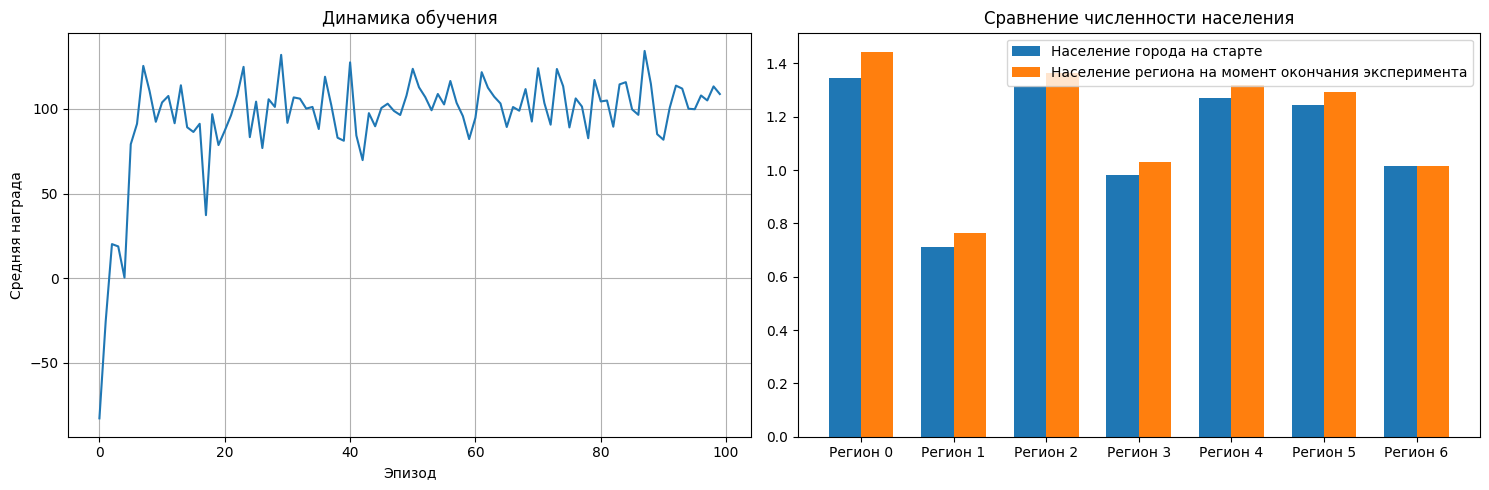

In [16]:
if __name__ == "__main__":
    simulator = MADDPG()  # Создание экземпляра класса MADDPG
    simulator.train()  # Запуск процесса обучения